# GD1

In this notebook we replace the results in ` Alvey et al. 2024` on the GD1 stream. 

In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from autocvd import autocvd
autocvd(num_gpus = 1)

import jax 
import jax.numpy as jnp
from jax import jit, random
import equinox as eqx
from jax.sharding import Mesh, PartitionSpec, NamedSharding

# jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt


import numpy as np
from astropy import units as u
from astropy import constants as c

import odisseo
from odisseo import construct_initial_state
from odisseo.integrators import leapfrog
from odisseo.dynamics import direct_acc, DIRECT_ACC, DIRECT_ACC_LAXMAP, DIRECT_ACC_FOR_LOOP, DIRECT_ACC_MATRIX
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL
from odisseo.initial_condition import Plummer_sphere, ic_two_body, sample_position_on_sphere, inclined_circular_velocity, sample_position_on_circle, inclined_position
from odisseo.utils import center_of_mass
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.visualization import create_3d_gif, create_projection_gif, energy_angular_momentum_plot
from odisseo.potentials import MyamotoNagai, NFW

from odisseo.utils import halo_to_gd1_velocity_vmap, halo_to_gd1_vmap, projection_on_GD1


plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 15,
})
plt.style.use('default')

# 

## Setting up the simulation parameters and configurations

In [2]:
from odisseo.option_classes import DIFFRAX_BACKEND, TSIT5

In [3]:
code_length = 10 * u.kpc
code_mass = 1e4 * u.Msun
G = 1
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  


config = SimulationConfig(N_particles = 10_000, 
                          return_snapshots = True, 
                          num_snapshots = 1000, 
                          num_timesteps = 1000, 
                          external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                          acceleration_scheme = DIRECT_ACC_MATRIX,
                          softening = (0.1 * u.pc).to(code_units.code_length).value,
                          integrator=DIFFRAX_BACKEND,
                          fixed_timestep=False,
                          diffrax_solver=TSIT5
                          ) #default values

params = SimulationParams(t_end = (3 * u.Gyr).to(code_units.code_time).value,  
                          Plummer_params= PlummerParams(Mtot=(10**4.05 * u.Msun).to(code_units.code_mass).value,
                                                        a=(100 * u.pc).to(code_units.code_length).value),
                           MN_params= MNParams(M = (68_193_902_782.346756 * u.Msun).to(code_units.code_mass).value,
                                              a = (3.0 * u.kpc).to(code_units.code_length).value,
                                              b = (0.280 * u.kpc).to(code_units.code_length).value),
                          NFW_params= NFWParams(Mvir=(4.3683325e11 * u.Msun).to(code_units.code_mass).value,
                                               r_s= (16.0 * u.kpc).to(code_units.code_length).value,),      
                          PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),                    
                          G=code_units.G, ) 


key = random.PRNGKey(500000000)

#set up the particles in the initial state
positions, velocities, mass = Plummer_sphere(key=key, params=params, config=config)


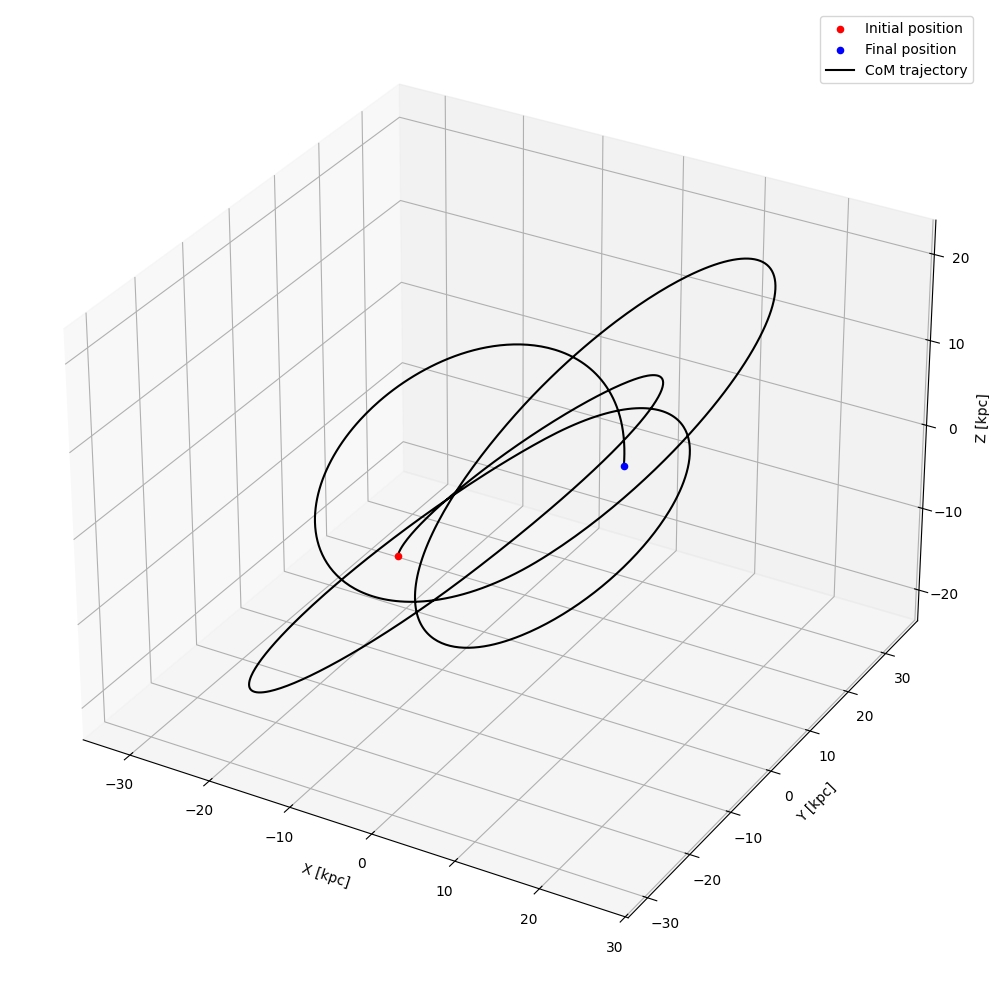

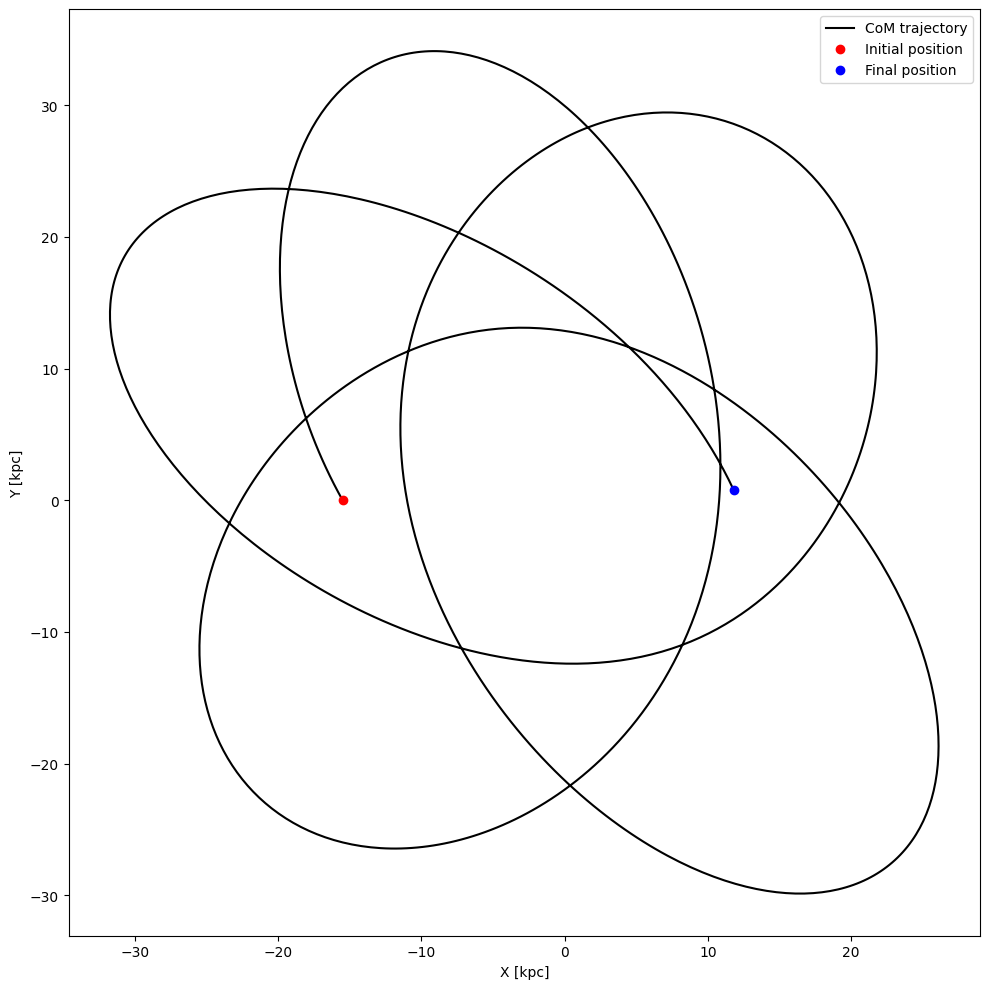

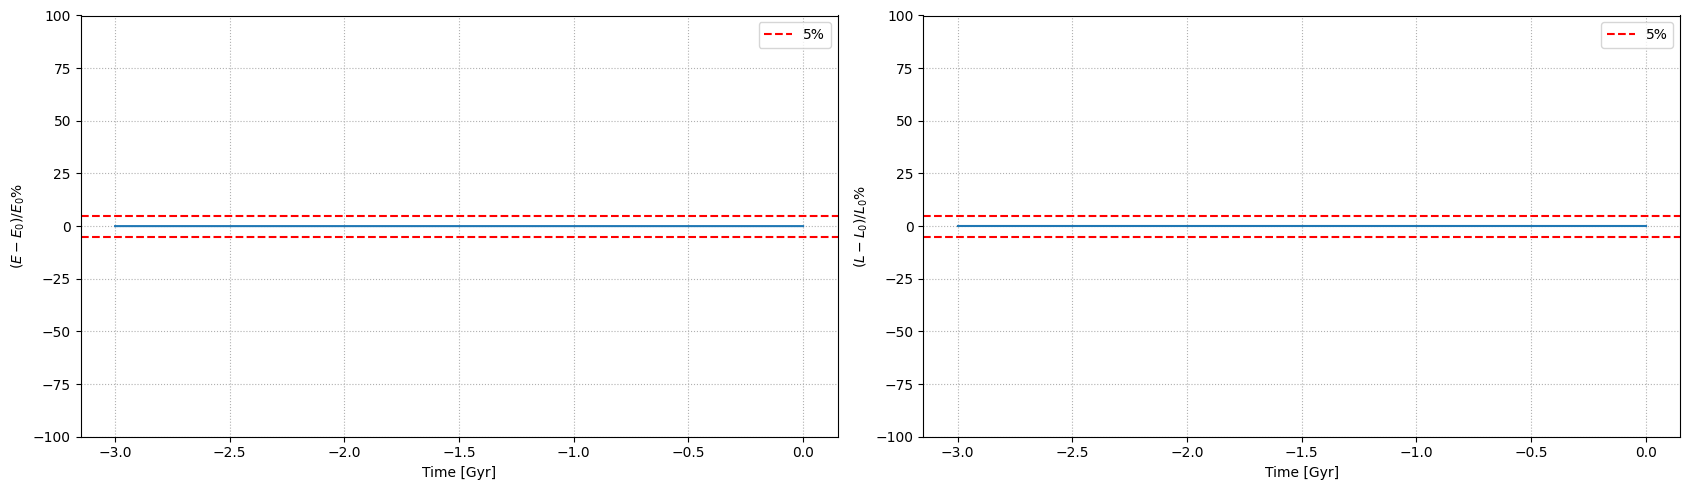

In [4]:
#the center of mass needs to be integrated backwards in time first 
config_com = config._replace(N_particles=1,)
params_com = params._replace(t_end=-params.t_end,)



#this is the final position of the cluster, we need to integrate backwards in time 
pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)
mass_com = jnp.array([params_com.Plummer_params.Mtot])
final_state_com = construct_initial_state(pos_com_final, vel_com_final) # state is a (N_particles x 2 x 3)

#evolution in time
snapshots_com = time_integration(final_state_com, mass_com, config_com, params_com)

#we can plot the snapshots of simulations, the snapshot are NameTuple with states=(N_snapshots x N_particles x 2 x 3) array
pos_com, vel_com = snapshots_com.states[-1, :, 0], snapshots_com.states[-1, :, 1]

##### CoM orbit plot####
fig = plt.figure(figsize=(15, 10), tight_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(snapshots_com.states[-1, 0, 0, 0]* code_units.code_length.to(u.kpc), 
           snapshots_com.states[-1, 0, 0, 1]* code_units.code_length.to(u.kpc), 
           snapshots_com.states[-1,0, 0, 2]* code_units.code_length.to(u.kpc),c='r', label='Initial position')
ax.scatter(snapshots_com.states[0, 0, 0, 0]* code_units.code_length.to(u.kpc), 
           snapshots_com.states[0, 0, 0, 1]* code_units.code_length.to(u.kpc), 
           snapshots_com.states[0,0, 0, 2]* code_units.code_length.to(u.kpc), c='b', label='Final position')
ax.plot(snapshots_com.states[:, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[:, 0, 0, 1]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[:,0, 0, 2]* code_units.code_length.to(u.kpc), 'k-', label='CoM trajectory')
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
ax.set_zlabel("Z [kpc]")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 10), tight_layout=True)
ax = fig.add_subplot(111)
ax.plot(snapshots_com.states[:, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[:, 0, 0, 1]* code_units.code_length.to(u.kpc), 'k-', label='CoM trajectory')
ax.plot(snapshots_com.states[-1, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[-1, 0, 0, 1]* code_units.code_length.to(u.kpc), 'ro', label='Initial position')
ax.plot(snapshots_com.states[0, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[0, 0, 0, 1]* code_units.code_length.to(u.kpc), 'bo', label='Final position')
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
ax.legend()

#check conservation of energy and angular momentum
energy_angular_momentum_plot(snapshots_com, code_units,)

## Dwarf Galaxy position and velocity

In [5]:
# Add the center of mass position and velocity to the Plummer sphere particles
positions = positions + pos_com
velocities = velocities + vel_com

#initialize the initial state
initial_state_stream = construct_initial_state(positions, velocities)

#run the simulation
snapshots = time_integration(initial_state_stream, mass, config, params)

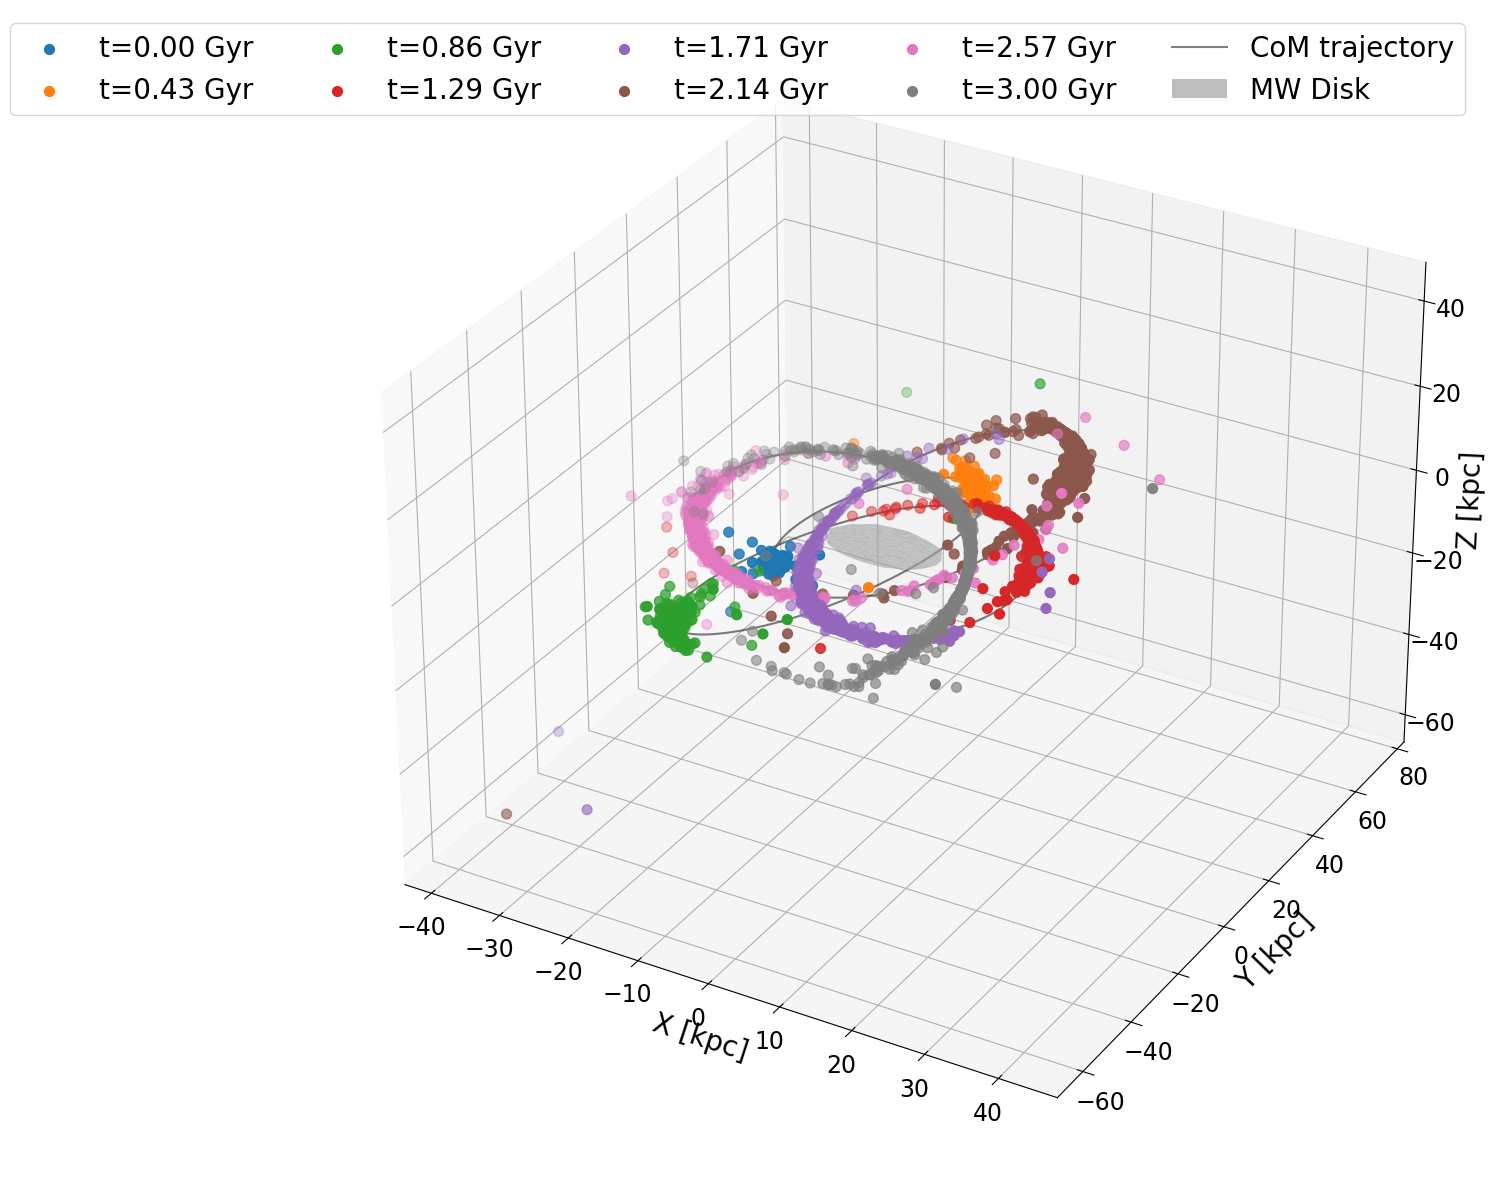

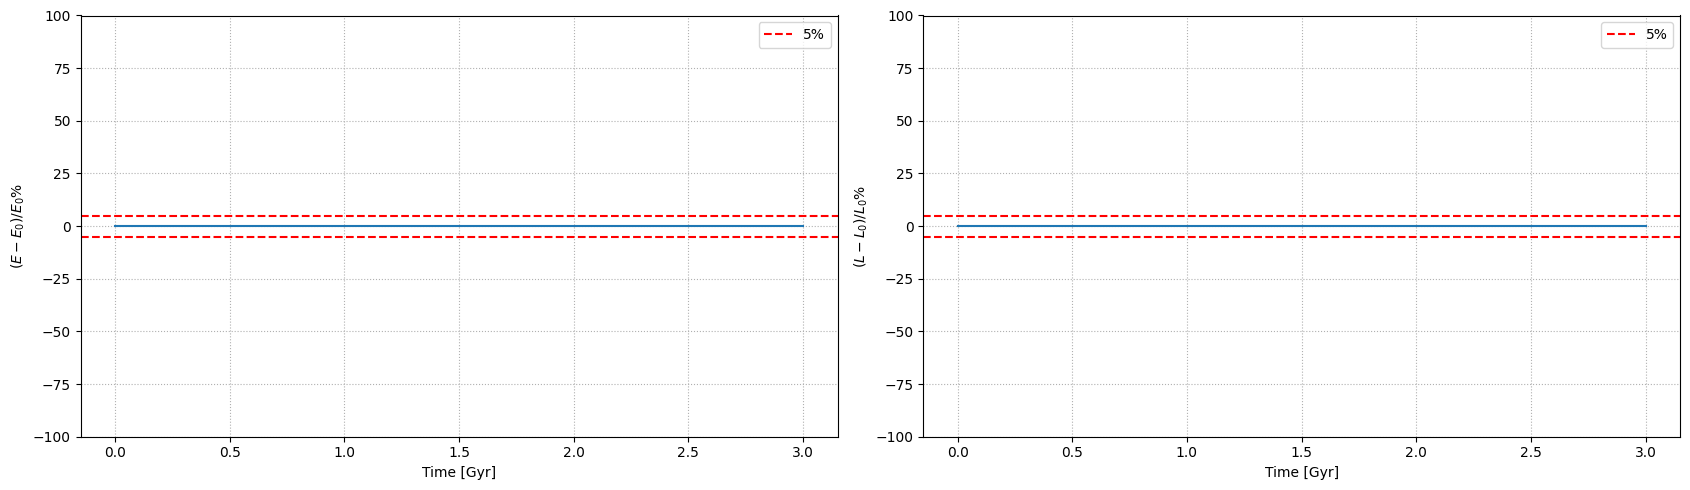

In [6]:
plt.style.use('default')

# Create a circular ring (solid line)
radius = 8 #kpc
z_disk = 0
theta = np.linspace(0, 2*np.pi, 500)
x_ring = radius * np.cos(theta)
y_ring = radius * np.sin(theta)
z_ring = np.full_like(theta, z_disk)

fig = plt.figure(figsize=(15, 15), tight_layout=True,)
ax = fig.add_subplot(111, projection='3d')
for i in np.linspace(0, config.num_snapshots, 8, dtype=int):
    ax.scatter(snapshots.states[i, :, 0, 0] * code_units.code_length.to(u.kpc), 
               snapshots.states[i, :, 0, 1] * code_units.code_length.to(u.kpc), 
               snapshots.states[i, :, 0, 2] * code_units.code_length.to(u.kpc), 
               label=f"t={(snapshots.times[i]*code_units.code_time).to(u.Gyr):.2f}",
               s=50)


ax.plot(snapshots_com.states[:, 0, 0, 0]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[:, 0, 0, 1]* code_units.code_length.to(u.kpc), 
        snapshots_com.states[:,0, 0, 2]* code_units.code_length.to(u.kpc), 'k-', alpha=0.5, label='CoM trajectory')
# ax.scatter(0, 0, 0, c='k', s=100, )

# Ring (Milky Way disk)
# ax.plot(x_ring, y_ring, z_ring, color="royalblue", linewidth=3, label="MW Disk")

r = 8
n = 500


# Random polar points inside the disk
theta = np.random.uniform(0, 2*np.pi, n)
rho = r * np.sqrt(np.random.uniform(0, 1, n))  # ensures uniform density
x = rho * np.cos(theta)
y = rho * np.sin(theta)
z = np.zeros_like(x)

# Triangular surface
ax.plot_trisurf(x, y, z, color="lightgray", alpha=0.7, linewidth=0, label="MW Disk")

ax.set_xlabel('X [kpc]', fontsize=20)
ax.set_ylabel('Y [kpc]', fontsize=20)
ax.set_zlabel('Z [kpc]', fontsize=20)
ax.legend(fontsize=20, ncol=5)


ax.tick_params(axis='both', which='major', labelsize=17)  # 
# ax.axis('off')
fig.savefig("gd1_orbit.pdf", bbox_inches='tight')



# Remove the grid
# ax.grid(False)

energy_angular_momentum_plot(snapshots, code_units,)


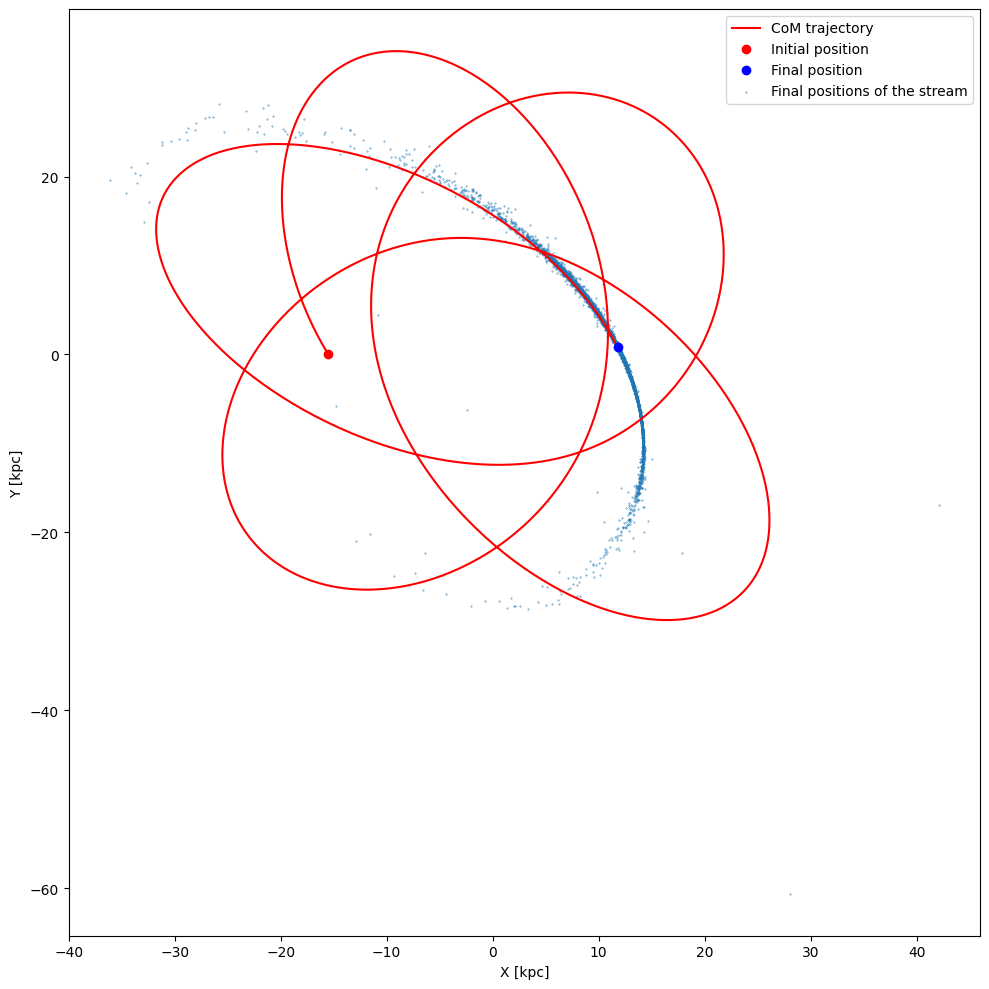

In [7]:
fig = plt.figure(figsize=(10, 10), tight_layout=True)
ax = fig.add_subplot(111)
ax.plot(snapshots_com.states[:, 0, 0, 0]* code_units.code_length.to(u.kpc), 
    snapshots_com.states[:, 0, 0, 1]* code_units.code_length.to(u.kpc), 'r-', label='CoM trajectory')
ax.plot(snapshots_com.states[-1, 0, 0, 0]* code_units.code_length.to(u.kpc), 
    snapshots_com.states[-1, 0, 0, 1]* code_units.code_length.to(u.kpc), 'ro', label='Initial position')
ax.plot(snapshots_com.states[0, 0, 0, 0]* code_units.code_length.to(u.kpc), 
    snapshots_com.states[0, 0, 0, 1]* code_units.code_length.to(u.kpc), 'bo', label='Final position')
ax.scatter(snapshots.states[-1, :, 0, 0]* code_units.code_length.to(u.kpc), 
    snapshots.states[-1, :, 0, 1]* code_units.code_length.to(u.kpc), s=0.1, label='Final positions of the stream')
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
# ax.set_xlim(-30, 30)
# ax.set_ylim(-30, 30)
ax.legend()

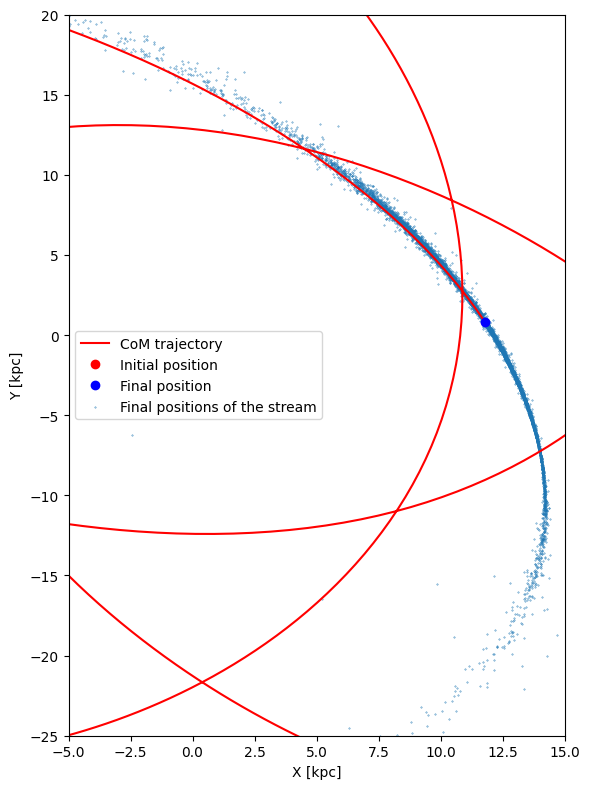

In [8]:
fig = plt.figure(figsize=(6, 8), tight_layout=True)
ax = fig.add_subplot(111)
conversion = code_units.code_length.to(u.kpc)
ax.plot(snapshots_com.states[:, 0, 0, 0]*conversion, 
        snapshots_com.states[:, 0, 0, 1]* conversion, 'r-', label='CoM trajectory')
ax.plot(snapshots_com.states[-1, 0, 0, 0]*conversion,
         snapshots_com.states[-1, 0, 0, 1]*conversion, 'ro', label='Initial position')
ax.plot(snapshots_com.states[0, 0, 0, 0]*conversion, 
        snapshots_com.states[0, 0, 0, 1]*conversion, 'bo', label='Final position')
ax.scatter(snapshots.states[-1, :, 0, 0]*conversion, 
           snapshots.states[-1, :, 0, 1]*conversion, s=0.1, label='Final positions of the stream')
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
ax.set_xlim(-5, 15)
ax.set_ylim(-25, 20)
ax.legend()

In [9]:
final_state = snapshots.states[-1].copy()
final_positions, final_velocities = final_state[:, 0], final_state[:, 1]

final_positions = final_positions * code_units.code_length.to(u.kpc)
final_velocities = final_velocities * code_units.code_velocity.to(u.kpc / u.Myr)

## Projection on the GD1 plane 

(-250.0, 250.0)

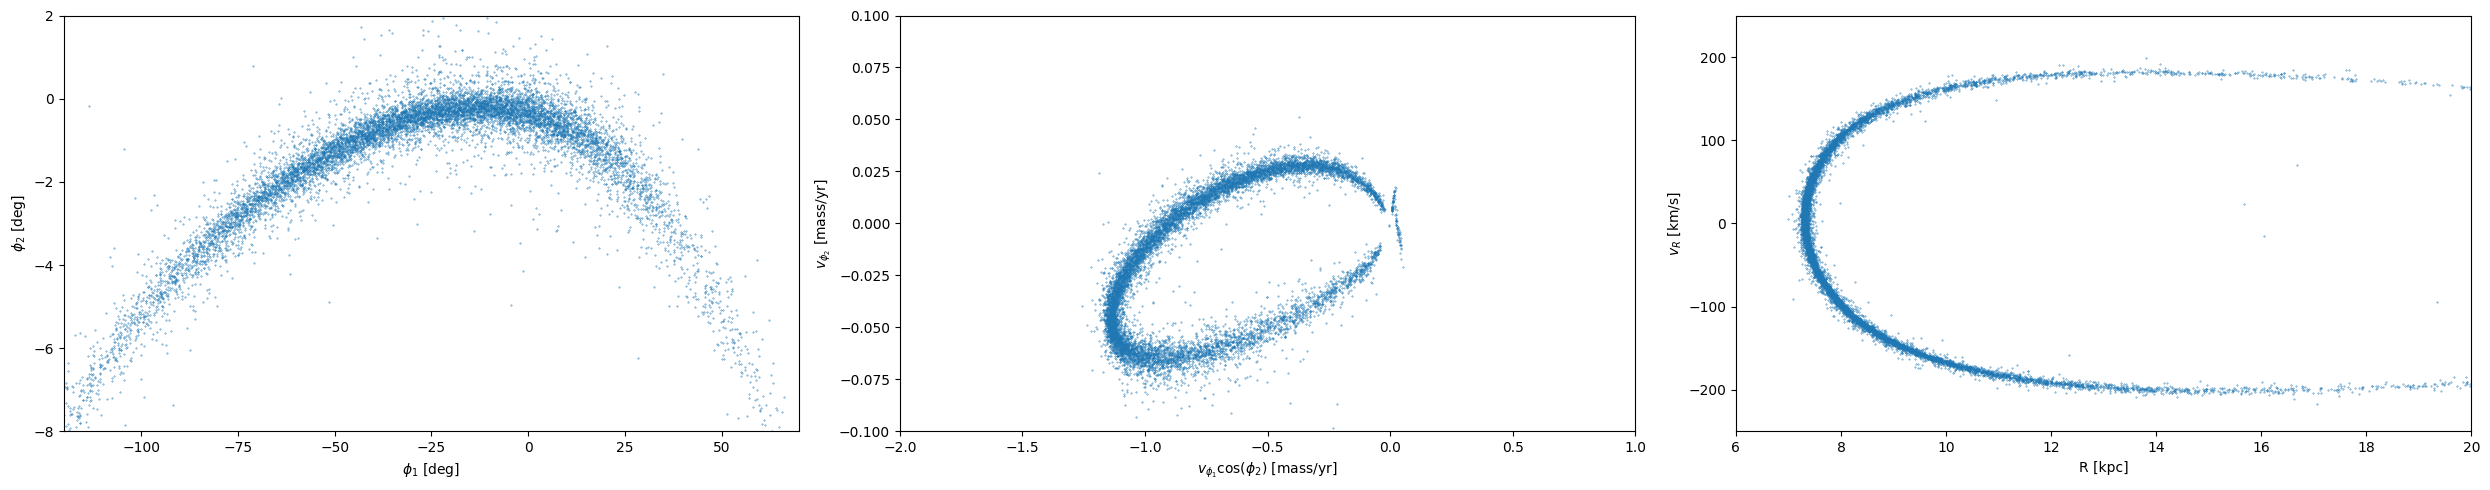

In [10]:
s = projection_on_GD1(final_state, code_units=code_units,)
R = s[:, 0]  # kpc
phi1 = s[:, 1]  # deg
phi2 = s[:, 2]  # deg
vR = s[:, 3]  # km/s
v1_cosphi2 = s[:, 4]  # mass/yr
v2 = s[:, 5]  # mass/yr

fig = plt.figure(figsize=(25, 5), tight_layout=True)

ax = fig.add_subplot(131)
ax.scatter(phi1, phi2, s=0.1)
ax.set_xlabel("$\phi_1$ [deg]")
ax.set_ylabel("$\phi_2$ [deg]")
ax.set_xlim(-120, 70)
ax.set_ylim(-8, 2)

ax = fig.add_subplot(132)
ax.scatter(v1_cosphi2 ,
           v2 ,
            s=0.1)
ax.set_xlabel("$v_{\phi_1}\cos(\phi_2)$ [mass/yr]")
ax.set_ylabel("$v_{\phi_2}$ [mass/yr]")
ax.set_xlim(-2., 1.0)
ax.set_ylim(-0.10, 0.10)

ax = fig.add_subplot(133)
ax.scatter(R, vR , s=0.1)
ax.set_xlabel("R [kpc]")
ax.set_ylabel("$v_R$ [km/s]")
ax.set_xlim(6, 20)
ax.set_ylim(-250, 250)


/tmp/ipykernel_2199254/3570116978.py:21: RuntimeWarning: divide by zero encountered in log10
  im1 = ax.pcolormesh(PHI1, PHI2, np.log10(counts1), cmap='coolwarm')
/tmp/ipykernel_2199254/3570116978.py:31: RuntimeWarning: divide by zero encountered in log10
  im2 = ax.pcolormesh(V1, V2, np.log10(counts2), cmap='coolwarm')
/tmp/ipykernel_2199254/3570116978.py:40: RuntimeWarning: divide by zero encountered in log10
  im3 = ax.pcolormesh(R_GRID, VR_GRID, np.log10(counts3), cmap='coolwarm')


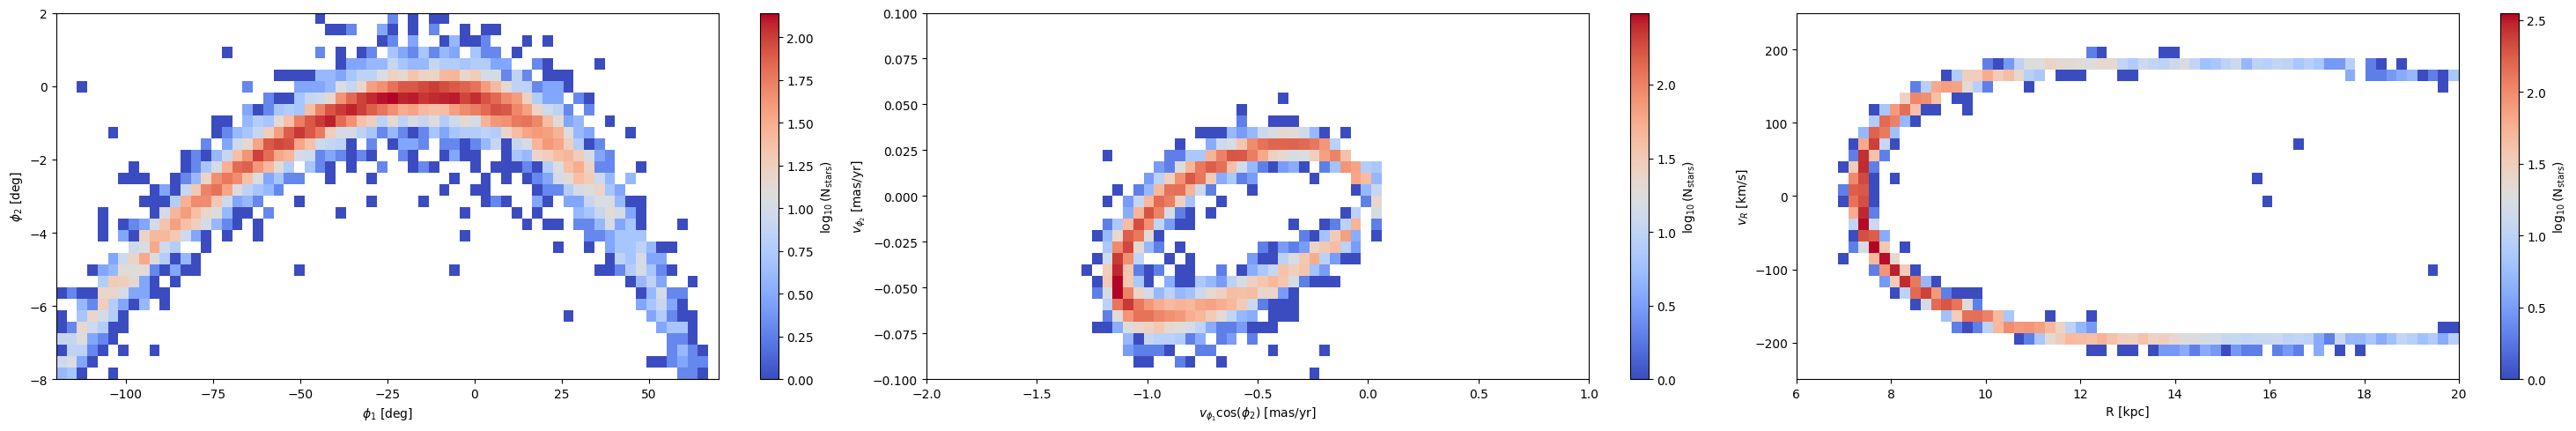

In [11]:
import matplotlib.colors as colors

fig = plt.figure(figsize=(30, 5), tight_layout=True)

# Define bin edges and create meshgrids
phi1_bins = jnp.linspace(-120, 70, 65)    # 64 bins
phi2_bins = jnp.linspace(-8, 2, 33)       # 32 bins
v1_bins = jnp.linspace(-2., 1.0, 65)      # 64 bins  
v2_bins = jnp.linspace(-0.10, 0.10, 33)   # 32 bins
R_bins = jnp.linspace(6, 20, 65)          # 64 bins
vR_bins = jnp.linspace(-250, 250, 33)     # 32 bins

# Create meshgrids for bin edges (not centers)
PHI1, PHI2 = jnp.meshgrid(phi1_bins, phi2_bins, indexing='ij')
V1, V2 = jnp.meshgrid(v1_bins, v2_bins, indexing='ij')
R_GRID, VR_GRID = jnp.meshgrid(R_bins, vR_bins, indexing='ij')

# Create 2D histograms
ax = fig.add_subplot(131)
counts1 = jnp.histogram2d(phi1, phi2, bins=[phi1_bins, phi2_bins])[0]
im1 = ax.pcolormesh(PHI1, PHI2, np.log10(counts1), cmap='coolwarm')
ax.set_xlabel("$\phi_1$ [deg]")
ax.set_ylabel("$\phi_2$ [deg]")
ax.set_xlim(-120, 70)
ax.set_ylim(-8, 2)
# Define a normalization that centers white at 0
plt.colorbar(im1, ax=ax, label=r'$\log_{10}(\text{N}_{\text{stars}})$',  )

ax = fig.add_subplot(132)
counts2 = jnp.histogram2d(v1_cosphi2, v2, bins=[v1_bins, v2_bins])[0]
im2 = ax.pcolormesh(V1, V2, np.log10(counts2), cmap='coolwarm')
ax.set_xlabel("$v_{\phi_1}\cos(\phi_2)$ [mas/yr]")
ax.set_ylabel("$v_{\phi_2}$ [mas/yr]")
ax.set_xlim(-2., 1.0)
ax.set_ylim(-0.10, 0.10)
plt.colorbar(im2, ax=ax, label=r'$\log_{10}(\text{N}_{\text{stars}})$')

ax = fig.add_subplot(133)
counts3 = jnp.histogram2d(R, vR, bins=[R_bins, vR_bins])[0]
im3 = ax.pcolormesh(R_GRID, VR_GRID, np.log10(counts3), cmap='coolwarm')
ax.set_xlabel("R [kpc]")
ax.set_ylabel("$v_R$ [km/s]")
ax.set_xlim(6, 20)
ax.set_ylim(-250, 250)
plt.colorbar(im3, ax=ax, label=r'$\log_{10}(\text{N}_{\text{stars}})$')

(-8.0, 2.0)

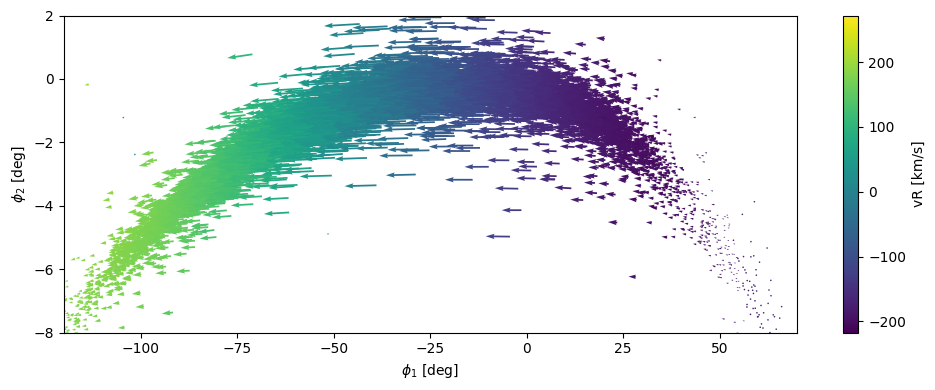

In [12]:
# Plotting the vector field of velocities
fig  = plt.figure(figsize=(10, 4), tight_layout=True)
ax = fig.add_subplot(111)
vectorf_field = ax.quiver(phi1, 
                            phi2,
                            v1_cosphi2/jnp.cos(jnp.deg2rad(phi2)),
                            v2,
                            vR,
                            scale=25,)
plt.colorbar(vectorf_field, ax=ax, label='vR [km/s]')
ax.set_xlabel("$\phi_1$ [deg]")
ax.set_ylabel("$\phi_2$ [deg]")
ax.set_xlim(-120, 70)
ax.set_ylim(-8, 2)

In [13]:
# np.savez('/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz',
#          x=s,
#          theta=np.array([params.t_end * code_units.code_time.to(u.Gyr),
#                          params.Plummer_params.Mtot * code_units.code_mass.to(u.Msun),
#                          params.Plummer_params.a * code_units.code_length.to(u.kpc),
#                          params.NFW_params.Mvir * code_units.code_mass.to(u.Msun),
#                          params.NFW_params.r_s * code_units.code_length.to(u.kpc),
#                          params.MN_params.M * code_units.code_mass.to(u.Msun),
#                          params.MN_params.a * code_units.code_length.to(u.kpc),]))



# Plummer parameters dependence 

(array([9.968e+03, 2.100e+01, 6.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([5.59819222e-04, 1.97572753e-01, 3.94585669e-01, 5.91598630e-01,
        7.88611531e-01, 9.85624433e-01, 1.18263745e+00, 1.37965035e+00,
        1.57666326e+00, 1.77367616e+00, 1.97068906e+00]),
 <BarContainer object of 10 artists>)

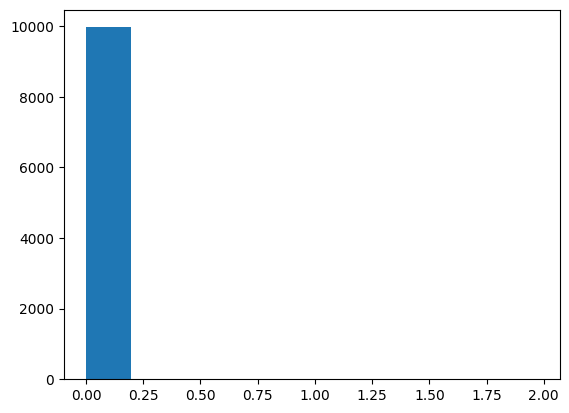

In [14]:
plt.hist(jnp.linalg.norm(snapshots.states[0, :, 0] - snapshots_com.states[-1, :, 0], axis=1))

/tmp/ipykernel_2199254/101339770.py:7: UserWarning: The Figure parameters 'layout' and 'constrained_layout' cannot be used together. Please use 'layout' only.
  fig = plt.figure(figsize=(15, 7), constrained_layout=False, layout='tight', rasterized=True)


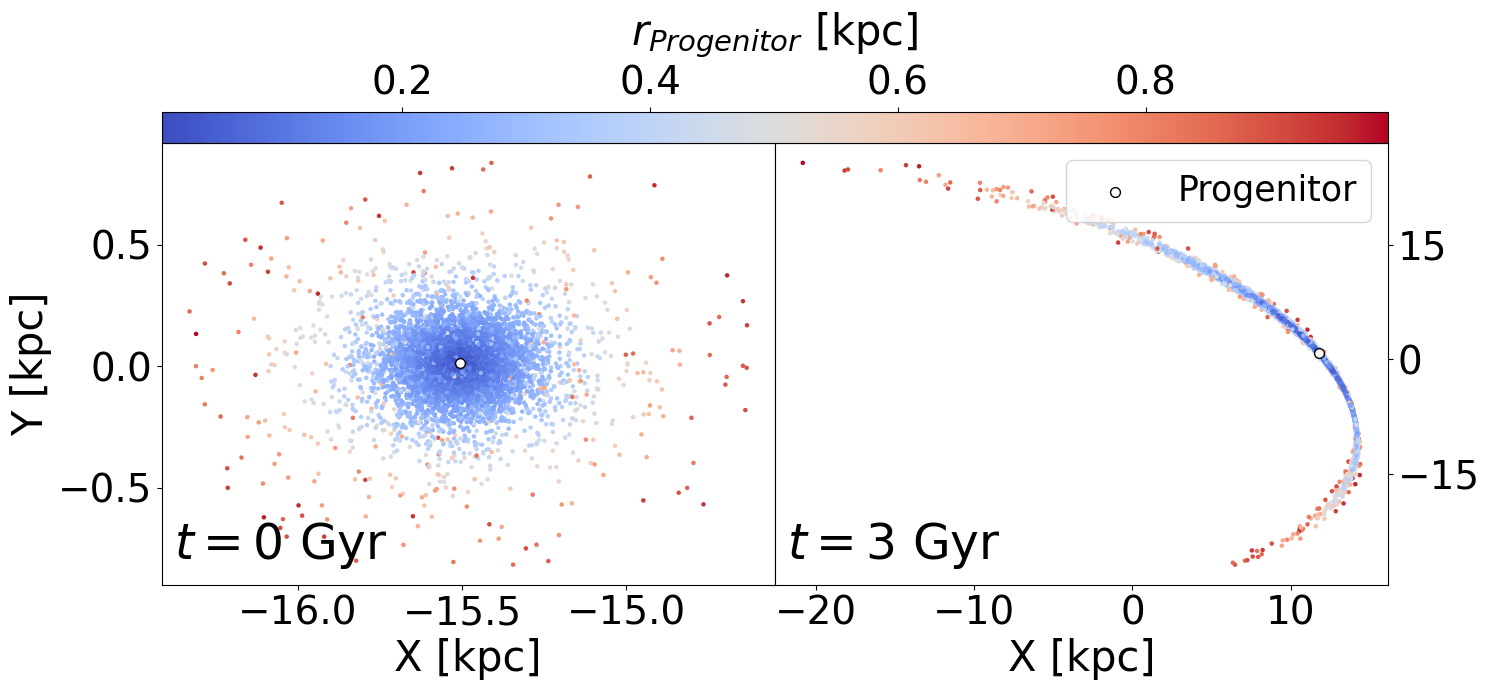

In [20]:
# ...existing code...
colormap = 'coolwarm'
fontsize = 30
mask = jnp.linalg.norm(snapshots.states[0, :, 0] - snapshots_com.states[-1, :, 0], axis=1) < 0.1


fig = plt.figure(figsize=(15, 7), constrained_layout=False, layout='tight', rasterized=True)
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[0.07, 1.0], hspace=0.0, wspace=0.0)

ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

dist0 = jnp.linalg.norm(snapshots.states[0, :, 0] - snapshots_com.states[-1, :, 0], axis=1) * code_units.code_length.to(u.kpc)
vmin, vmax = float(np.asarray(dist0[mask]).min()), float(np.asarray(dist0[mask]).max())

sc1 = ax1.scatter(
    snapshots.states[0, :, 0, 0][mask] * code_units.code_length.to(u.kpc),
    snapshots.states[0, :, 0, 1][mask] * code_units.code_length.to(u.kpc),
    s=5, c=dist0[mask], cmap=colormap, vmin=vmin, vmax=vmax
)
ax1.scatter(
    snapshots_com.states[-1, :, 0, 0]*code_units.code_length.to(u.kpc),
    snapshots_com.states[-1, :, 0, 1]*code_units.code_length.to(u.kpc),
    s=50, facecolors='white', edgecolors='black', marker='o'
)
ax1.set_xlabel("X [kpc]", fontsize=fontsize)
ax1.set_ylabel("Y [kpc]", fontsize=fontsize)

sc2 = ax2.scatter(
    snapshots.states[-1, :, 0, 0][mask] * code_units.code_length.to(u.kpc),
    snapshots.states[-1, :, 0, 1][mask] * code_units.code_length.to(u.kpc),
    s=5, c=dist0[mask], cmap=sc1.cmap, norm=sc1.norm
)
ax2.scatter(
    snapshots_com.states[0, :, 0, 0]*code_units.code_length.to(u.kpc),
    snapshots_com.states[0, :, 0, 1]*code_units.code_length.to(u.kpc),
    s=50, facecolors='white', edgecolors='black', marker='o', label='Progenitor'
)
ax2.set_xlabel("X [kpc]", fontsize=fontsize)
ax2.yaxis.set_ticks_position('right')
ax2.legend(fontsize=fontsize-5, loc='upper right')

# shared colorbar spanning both columns, placed on top
cax = fig.add_subplot(gs[0, :])
cb = fig.colorbar(sc1, cax=cax, orientation='horizontal', )
cb.set_label(r"$r_{Progenitor}$ [kpc]", fontsize=fontsize, labelpad=14)
cb.ax.xaxis.set_label_position('top')
cb.ax.xaxis.set_ticks_position('top')
cb.ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=fontsize-2)


#add text annotations
ax1.text(0.02, 0.03, "$t = 0$ Gyr", transform=ax1.transAxes,
         ha="left", va="bottom", fontsize=fontsize+5, color="k", zorder=10)

ax2.text(0.02, 0.03, "$t = 3$ Gyr", transform=ax2.transAxes,
         ha="left", va="bottom", fontsize=fontsize+5, color="k", zorder=10)


#ticks

from matplotlib.ticker import MaxNLocator

# Reduce number of ticks and set tick label size for each subplot
ax1.xaxis.set_major_locator(MaxNLocator(nbins=4))  # <= max ~4 ticks on X
ax1.yaxis.set_major_locator(MaxNLocator(nbins=4))  # <= max ~4 ticks on Y
ax1.tick_params(axis='both', which='major', labelsize=fontsize-2)

ax2.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax2.tick_params(axis='both', which='major', labelsize=fontsize-2)
fig.savefig("figure_2.pdf", dpi=300, bbox_inches='tight', )


# External potential parameters dependence

In [18]:
config = config._replace(N_particles=10_000,
                        return_snapshots=False, )
config_com = config_com._replace(return_snapshots=False, )

@jit
def run_simulation(params_for_sims):
    Mvir, r_s = params_for_sims
    new_params = params._replace(NFW_params= NFWParams(Mvir=Mvir,
                                               r_s= r_s,),)
    #we also update the t_end parameter for the center of mass
    new_params_com = new_params._replace(
                t_end=-new_params.t_end # Update the t_end parameter for the center of mass
                )
    
    #Final position and velocity of the center of mass
    pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
    vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)
    mass_com = jnp.array([params.Plummer_params.Mtot]) 
    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=new_params_com)
    #we calculate the final position and velocity of the center of mass
    pos_com = final_state_com[:, 0]
    vel_com = final_state_com[:, 1]

    #we construct the initial state of the Plummer sphere
    positions, velocities, mass = Plummer_sphere(key=key, params=new_params, config=config)
    #we add the center of mass position and velocity to the Plummer sphere particles
    positions = positions + pos_com
    velocities = velocities + vel_com
    #initialize the initial state
    initial_state_stream = construct_initial_state(positions, velocities, )
    #run the simulation
    final_state = time_integration(initial_state_stream, mass, config=config, params=new_params)
    return final_state


new_params = jnp.array([[params.NFW_params.Mvir * 0.8,
                         params.NFW_params.r_s * 0.8],
                        [params.NFW_params.Mvir * 0.8,
                        params.NFW_params.r_s * 1.2],
                        [params.NFW_params.Mvir * 1.2,
                        params.NFW_params.r_s * 0.8],
                        [params.NFW_params.Mvir * 1.2,
                        params.NFW_params.r_s * 1.2],])

new_final_states = jax.vmap(run_simulation)(new_params)

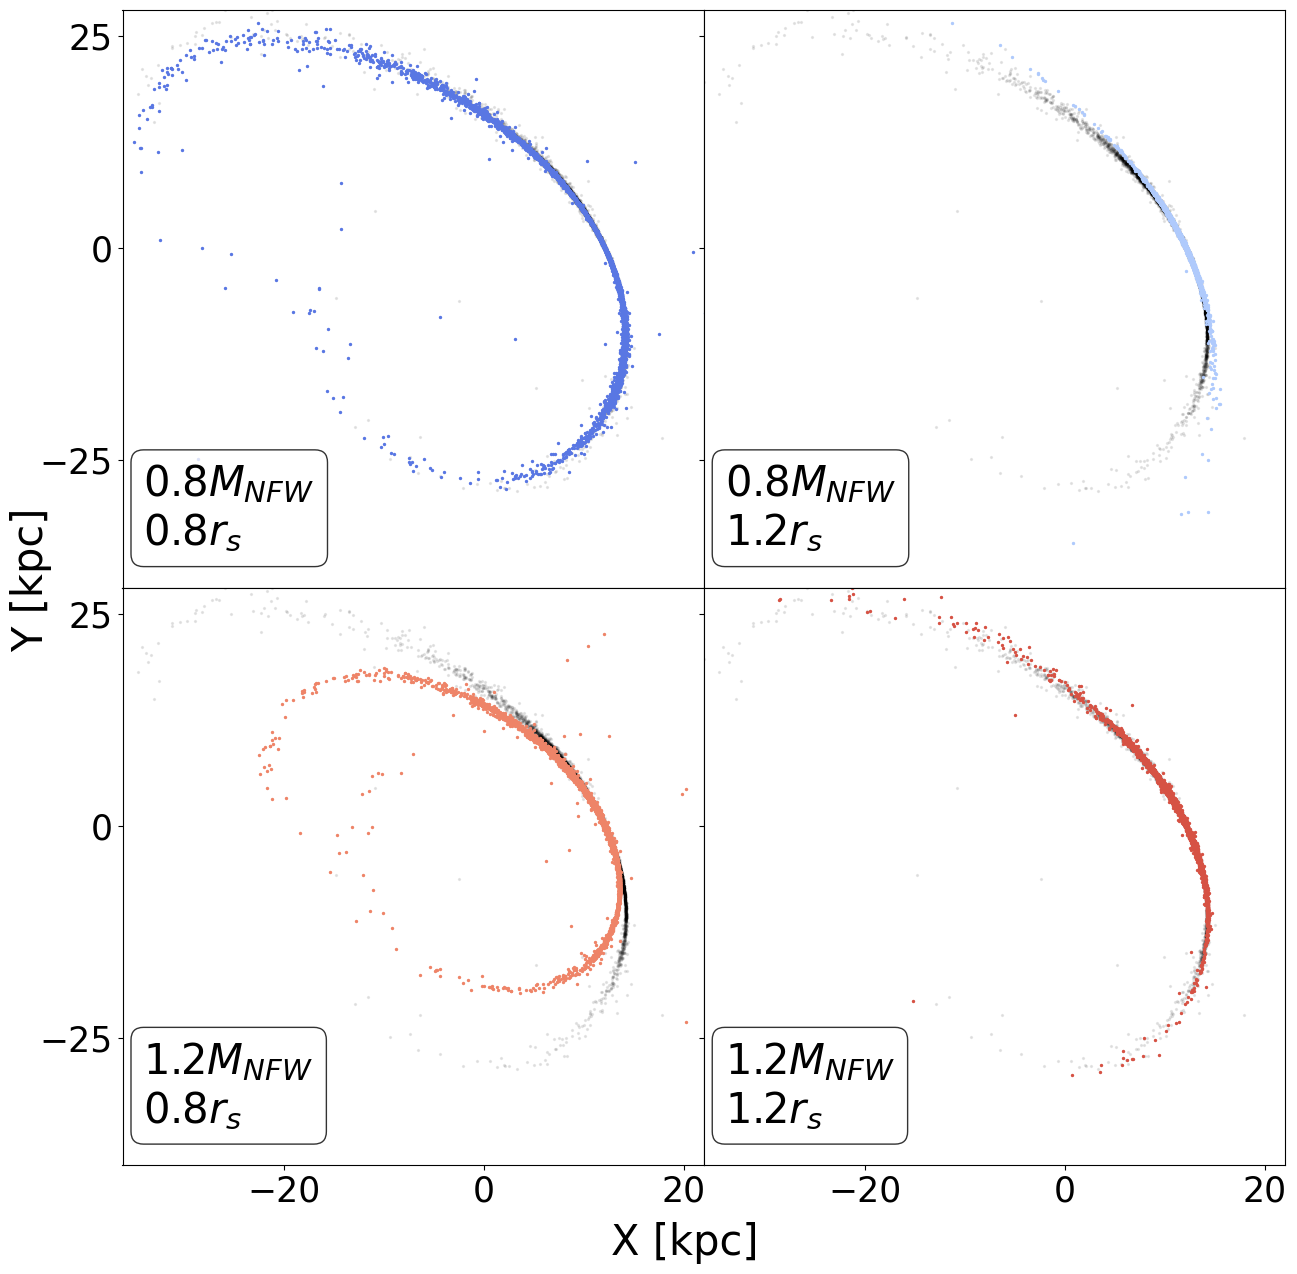

In [21]:
# ...existing code...
from matplotlib.ticker import MaxNLocator
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

def plot_external_potential_grid(new_final_states,
                                 snapshots,
                                 new_params,
                                 labels_fontsize=20,
                                 ticks_fontsize=20,
                                 xy_labelpad=0,
                                 n_xticks=4,
                                 n_yticks=4,
                                 colors=None):
    """2x2 grid; each panel colored by its (Mvir, r_s) ratio; legend in lower left."""
    

    base_Mvir = params.NFW_params.Mvir
    base_rs = params.NFW_params.r_s

    if colors is None:
        cmap = plt.get_cmap('coolwarm')
        samples = [0.10, 0.35, 0.80, 0.90]
        colors = [matplotlib.colors.to_hex(cmap(s)) for s in samples]

    fig, axes = plt.subplots(2, 2, figsize=(15, 15), sharex=True, sharey=True, rasterized=True)
    fig.subplots_adjust(wspace=0.0, hspace=0.0)

    x0 = snapshots.states[-1, :, 0, 0] * code_units.code_length.to(u.kpc)
    y0 = snapshots.states[-1, :, 0, 1] * code_units.code_length.to(u.kpc)
    xmin, xmax = float(x0.min()), 22.0
    ymin, ymax = -40, float(y0.max())

    for i, ax in enumerate(axes.flat):
        # Background (reference) stream (no legend entry)
        ax.scatter(
            snapshots.states[-1, :, 0, 0] * code_units.code_length.to(u.kpc),
            snapshots.states[-1, :, 0, 1] * code_units.code_length.to(u.kpc),
            c='black', alpha=0.08, s=2
        )

        Mvir_ratio = float(new_params[i, 0] / base_Mvir)
        rs_ratio = float(new_params[i, 1] / base_rs)

        # Colored scatter for this simulation
        ax.scatter(
            new_final_states[i][:, 0, 0] * code_units.code_length.to(u.kpc),
            new_final_states[i][:, 0, 1] * code_units.code_length.to(u.kpc),
            s=2,
            color=colors[i],
        )
        ax.text(-34, -35,
                f"{Mvir_ratio:.1f}$M_{{NFW}}$ \n{rs_ratio:.1f}$r_s$",
                fontsize=labels_fontsize,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        if i // 2 != 1:
            ax.tick_params(labelbottom=False)
        if i % 2 != 0:
            ax.tick_params(labelleft=False)

        ax.xaxis.set_major_locator(MaxNLocator(nbins=n_xticks))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=n_yticks))
        ax.tick_params(axis='both', which='major', labelsize=ticks_fontsize)

        # Legend in lower left
        # ax.legend(loc='lower left', fontsize=ticks_fontsize, frameon=True)

    fig.text(0.5, 0.02 + xy_labelpad, "X [kpc]", ha='center', fontsize=labels_fontsize)
    fig.text(0.02 + xy_labelpad, 0.5, "Y [kpc]", va='center', rotation='vertical', fontsize=labels_fontsize)

    return fig, axes

# Example call
fig, axes = plot_external_potential_grid(new_final_states,
                                         snapshots,
                                         new_params=new_params,
                                         labels_fontsize=30,
                                         ticks_fontsize=25,
                                         xy_labelpad=0.03,
                                         n_xticks=3,
                                         n_yticks=3,
                                         colors=None)
fig.savefig("figure_1.pdf", dpi=300, bbox_inches='tight', )

# ...existing code...